# Linear Regression (رگرسیون خطی)

**Linear Regression** یا **رگرسیون خطی** یکی از ساده‌ترین و پایه‌ای‌ترین الگوریتم‌های یادگیری ماشین برای مسائل **Regression** است.

در Classification، هدف پیش‌بینی یک **کلاس** است؛ اما در Regression هدف پیش‌بینی یک **مقدار عددی** است.

برای مثال:

```text
Classification:
Survived = 0 یا 1

Regression:
Fare = 32.5
```

در این پروژه Titanic، می‌خواهیم مقدار **Fare** یا هزینه بلیت مسافر را پیش‌بینی کنیم.

## ایده اصلی Linear Regression

Linear Regression تلاش می‌کند رابطه‌ای بین ویژگی‌های ورودی و مقدار عددی هدف پیدا کند.

در ساده‌ترین حالت، این رابطه به صورت یک خط نمایش داده می‌شود:

```text
y = mx + b
```

که در آن:

* `y` → مقدار پیش‌بینی‌شده
* `x` → ویژگی ورودی
* `m` → ضریب ویژگی
* `b` → مقدار ثابت یا Intercept

وقتی چند ویژگی داشته باشیم، رابطه به شکل زیر گسترش پیدا می‌کند:

```text
y = b + w₁x₁ + w₂x₂ + ... + wₙxₙ
```

برای مثال در پروژه Titanic ممکن است ویژگی‌هایی مانند این‌ها داشته باشیم:

```text
Pclass
Age
SibSp
Parch
```

و مدل تلاش می‌کند بر اساس این ویژگی‌ها مقدار `Fare` را پیش‌بینی کند.

## الگوریتم Linear Regression چگونه کار می‌کند؟

مدل ابتدا ضرایب مناسب برای ویژگی‌ها را پیدا می‌کند.

سپس مقدار پیش‌بینی‌شده را با مقدار واقعی مقایسه می‌کند.

```text
Features
   ↓
Linear Regression
   ↓
Predicted Fare
   ↓
مقایسه با Fare واقعی
   ↓
محاسبه خطا
```

مدل تلاش می‌کند ضرایبی را پیدا کند که باعث شوند **خطای پیش‌بینی حداقل شود**.

یکی از معیارهای مهمی که برای این کار استفاده می‌شود **Mean Squared Error (MSE)** است.

در MSE اختلاف مقدار واقعی و مقدار پیش‌بینی‌شده محاسبه شده و به توان دو می‌رسد.

## مثال ساده

فرض کنیم مقدار واقعی کرایه:

```text
Fare = 50
```

باشد و مدل مقدار:

```text
Predicted Fare = 45
```

را پیش‌بینی کند.

اختلاف این دو مقدار:

```text
50 - 45 = 5
```

است.

مدل در فرآیند آموزش تلاش می‌کند ضرایب خود را طوری تنظیم کند که این خطاها تا حد ممکن کاهش پیدا کنند.

## Linear Regression در پروژه Titanic

در این پروژه:

**Features:**

```text
Pclass
Age
SibSp
Parch
```

**Target:**

```text
Fare
```

بنابراین مدل تلاش می‌کند بر اساس مشخصات مسافر، مقدار کرایه بلیت را پیش‌بینی کند.

مثلاً:

```text
Pclass = 1
Age = 35
SibSp = 1
Parch = 0

        ↓

Linear Regression

        ↓

Predicted Fare = 75.4
```

## ارزیابی مدل

برای بررسی عملکرد مدل‌های Regression می‌توانیم از معیارهایی مانند:

* **MAE (Mean Absolute Error)**
* **MSE (Mean Squared Error)**
* **RMSE (Root Mean Squared Error)**
* **R² Score**

استفاده کنیم.

در این پروژه برای ساده نگه داشتن ارزیابی، از **MAE** استفاده می‌کنیم.

اگر:

```text
MAE = 10
```

باشد، می‌توان گفت مدل به طور متوسط حدود **10 واحد** با مقدار واقعی اختلاف دارد.

## تفاوت اصلی با Classification

```text
Classification
       ↓
پیش‌بینی کلاس
       ↓
Survived = 0 یا 1


Regression
       ↓
پیش‌بینی مقدار عددی
       ↓
Fare = 32.5
```

بنابراین در این دو پروژه با یک دیتاست یکسان، دو نوع مهم از مسائل یادگیری ماشین را تجربه می‌کنیم.

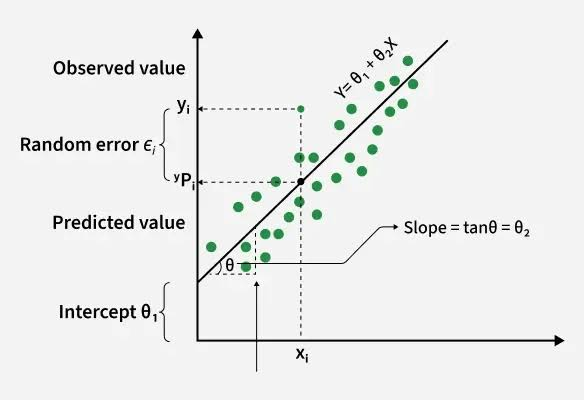


### Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

### Read Data

In [2]:
df = pd.read_csv("titanic.csv")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Select Target and Featurs

In [3]:
features = ["pclass", "age", "sibsp", "parch"]

X = df[features]
y = df["fare"]

### Show by scotter plot

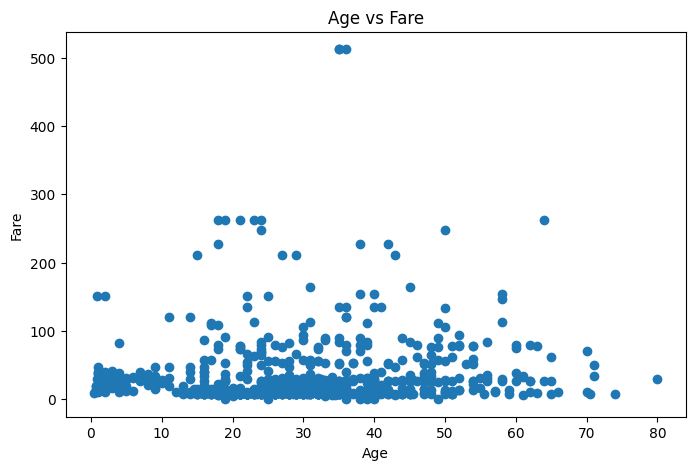

In [4]:
plt.figure(figsize=(8, 5))

plt.scatter(df["age"], df["fare"])

plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare")

plt.show()

### Removing incomplete data

In [5]:
X = X.dropna()

y = y[X.index]

### Split Data

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Modeling

In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
predictions = model.predict(X_test)
predictions

array([ 3.26804624e+01,  5.83251499e+01,  4.15763421e+01,  7.29625684e+01,
       -4.59939552e+00,  5.74421357e+01,  1.69667615e+01,  7.36326740e+01,
       -1.95035308e+00, -1.06733893e+00,  8.07988311e+01,  3.43581893e+01,
        7.83263915e+01, -3.71638137e+00,  7.10199373e+01,  6.13931362e+01,
       -1.15564035e+00,  8.65325253e+01,  3.53295048e+01,  7.42645264e+01,
        5.74833638e+01,  4.34247740e+01,  2.01622778e+01,  7.10199373e+01,
       -8.90736105e-01, -7.72195988e-03,  1.68880869e-01,  2.93171639e+01,
        7.03382802e+00, -3.71638137e+00,  5.88590963e+00,  3.89194549e+01,
        7.08433345e+01, -3.18657288e+00,  9.66030727e+00,  3.23686719e+00,
        4.06933279e+01,  6.73112779e+01,  6.64282637e+01, -6.01221815e+00,
        2.57193691e+01, -5.37530447e-01,  1.01757646e+02,  3.05612284e+01,
        8.67748663e+01,  3.49762992e+01,  5.28504622e+01,  3.68002210e+01,
        7.01369231e+01,  7.53241434e+01,  7.72667745e+01,  3.58593133e+01,
        7.90328028e+01, -

### Model Evaluation

In [9]:
mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 25.18167904393661


میزان اختلاف مدل با مقدار واقعی